In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/file_summary.csv')
df1['Condition'] = 'GH Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/file_summary.csv')
df2['Condition'] = 'GH Fed-Starved'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/file_summary.csv')
df3['Condition'] = 'GH Starved-Starved'



df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/file_summary.csv')
df4['Condition'] = 'SI Fed-Fed'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/file_summary.csv')
df5['Condition'] = 'SI Fed-Starved'

df6 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/file_summary.csv')
df6['Condition'] = 'SI Starved-Starved'


df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)

df[df['track'] == 30]['video_name'].unique()

array([], dtype=object)

/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_42976/4210969995.py:4: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


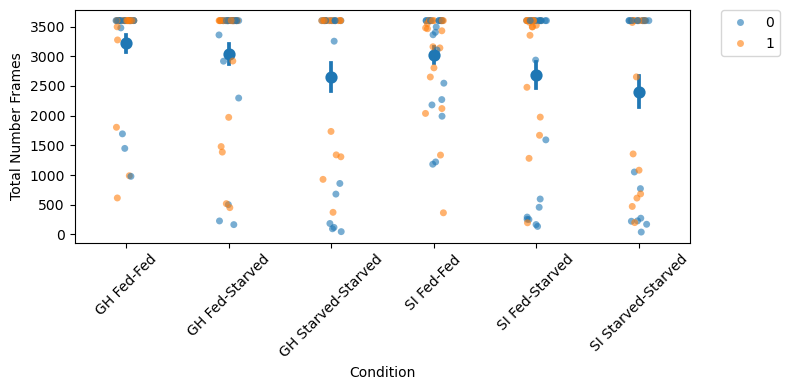

In [2]:
# PLOT
plt.figure(figsize=(8,4))

sns.pointplot(
    data=df,
    x='Condition',
    y='total_number_frames',
    errorbar='se',
    join=False,
)

sns.stripplot(
    data=df,
    x='Condition',
    y='total_number_frames',
    alpha=0.6,
    hue='track',
)

plt.xticks(rotation=45)
plt.ylabel('Total Number Frames')
plt.xlabel('Condition')

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.
)

plt.tight_layout()
plt.show()

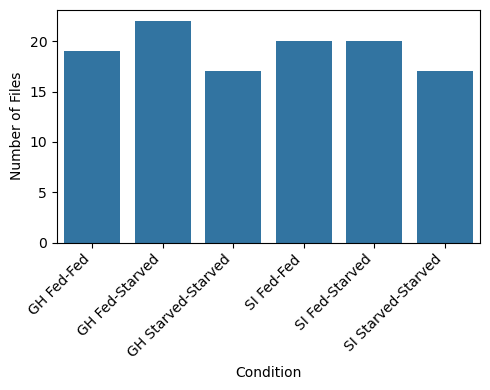

In [3]:
# count number of unique files per condition
count_df = (
    df.groupby('Condition')['video_name']
    .nunique()
    .reset_index(name='n_files')
)

plt.figure(figsize=(5,4))

sns.barplot(
    data=count_df,
    x='Condition',
    y='n_files'
)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Files')
plt.xlabel('Condition')

plt.tight_layout()
plt.show()

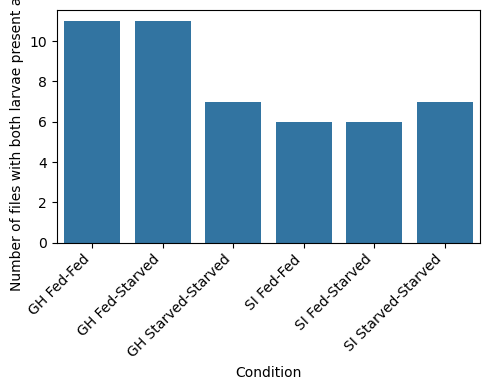

In [4]:
# one row per file
file_level = (
    df.groupby(['Condition', 'video_name'])['present_at_end']
    .all()
    .reset_index(name='both_present_at_end')
)

# count files where both larvae are present
count_df = (
    file_level.groupby('Condition')['both_present_at_end']
    .sum()
    .reset_index(name='n_files_both_present')
)

plt.figure(figsize=(5,4))

sns.barplot(
    data=count_df,
    x='Condition',
    y='n_files_both_present'
)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of files with both larvae present at end')
plt.xlabel('Condition')

plt.tight_layout()
plt.show()

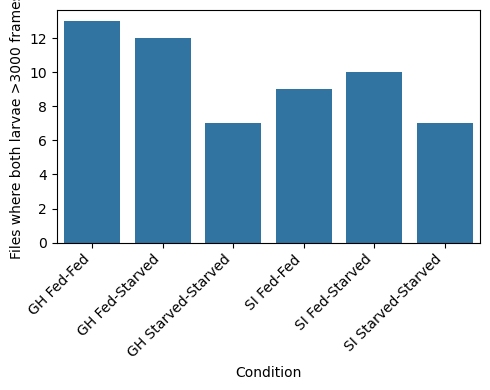

In [6]:
# check whether BOTH larvae in each file have >3000 frames
frames = (
    df.groupby(['Condition', 'video_name'])['total_number_frames']
    .apply(lambda x: (x > 3000).all())
    .reset_index(name='both_tracks_over_3000')
)

# count files per condition
frames_3000 = (
    frames.groupby('Condition')['both_tracks_over_3000']
    .sum()
    .reset_index(name='n_files_both_tracks_over_3000')
)

# plot
plt.figure(figsize=(5,4))

sns.barplot(
    data=frames_3000,
    x='Condition',
    y='n_files_both_tracks_over_3000'
)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Files where both larvae >3000 frames')
plt.xlabel('Condition')

plt.tight_layout()
plt.show()

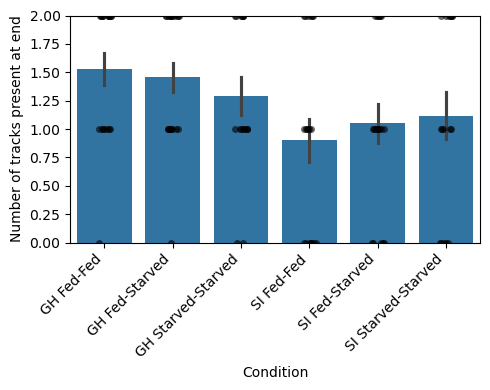

In [ ]:
# count how many tracks are present at end per file
file_level = (
    df.groupby(['Condition', 'video_name'])['present_at_end']
    .sum()
    .reset_index(name='n_tracks_present_at_end')
)

plt.figure(figsize=(5,4))

sns.barplot(
    data=file_level,
    x='Condition',
    y='n_tracks_present_at_end',
    errorbar='se'
)

sns.stripplot(
    data=file_level,
    x='Condition',
    y='n_tracks_present_at_end',
    color='black',
    alpha=0.6
)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of tracks present at end')
plt.xlabel('Condition')
plt.ylim(0, 2)

plt.tight_layout()
plt.show()